# 01 — Exploratory Data Analysis

## Objective
Load the Power BI semantic model export and produce a clean weekly **unit demand** table
for inventory forecasting.

## Data Source
Export from **V2_STATISTIQUES** semantic model (Power BI).

### Columns to export from the semantic model
| Column | Role |
|--------|------|
| `Date de Vente` | Transaction date |
| `No. magasin` | Store code |
| `Division Code corrigée` | Product division |
| `Quantité facturée` | **Target variable** — units sold |


## Output
- `data/processed/weekly_units.csv`
- `data/processed/store_region_map.csv`


---
## Cell 1 — Imports & Setup
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (13, 5)
sns.set_palette('husl')

PROJECT_ROOT   = Path('..')
DATA_RAW       = PROJECT_ROOT / 'data' / 'raw'
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
FIGURES        = PROJECT_ROOT / 'reports' / 'figures'
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

# Power BI adds these junk rows to every export — removing them
PBI_JUNK = [
    'Total',
    'No filters applied',
    'Exported data exceeded the allowed volume. Some data may have been omitted.'
]
print('✅ Setup complete')

✅ Setup complete


---
## Cell 2 — Load Sliced Exports (raw/slices CSV for each store)

---

In [3]:
SLICES_DIR = DATA_RAW / 'slices'
files = list(SLICES_DIR.glob('*.xlsx')) + list(SLICES_DIR.glob('*.csv'))
print(f'Found {len(files)} slice files')

slices = []
for f in files:
    s = pd.read_excel(f) if f.suffix == '.xlsx' else pd.read_csv(f)
    s = s[~s['Magasins'].isin(PBI_JUNK)].copy()
    slices.append(s)

raw = pd.concat(slices, ignore_index=True).drop_duplicates()
raw['Date de Vente']          = pd.to_datetime(raw['Date de Vente'], errors='coerce')
raw['Quantité facturée']      = pd.to_numeric(raw['Quantité facturée'], errors='coerce')
raw['No. magasin']            = raw['Magasins'].astype(str).str.strip()
raw['Division Code corrigée'] = raw['Division Code corrigée'].astype(str).str.strip()
raw = raw.dropna(subset=['Date de Vente', 'Quantité facturée'])

print(f'Combined rows: {len(raw):,} from {len(files)} files')
print(f'Date range   : {raw["Date de Vente"].min().date()} → {raw["Date de Vente"].max().date()}')

Found 32 slice files
Combined rows: 204,236 from 32 files
Date range   : 2023-11-02 → 2026-03-10


---
## Cell 3 — Clean & Filter
---

In [ ]:
# Drop test store 99 (only 4 weeks, placeholder) and 'nan' division rows
#CP20, CP05, and CP40 might have data quality problem therefore excluding it for now

EXCLUDE_STORES = ['CP99', 'nan', 'CP77 - Liquidation', 'CP100 - Liquidation', 'CP20 - Valleyfield', 'CP05 - Sherbrooke', 'CP40 - Thetford Mines']
raw = raw[~raw['No. magasin'].isin(EXCLUDE_STORES)].copy()
raw = raw[raw['Division Code corrigée'] != 'nan'].copy()

print(f'After cleaning : {len(raw):,} rows')
print(f'Stores         : {sorted(raw["No. magasin"].unique())}')
print(f'Divisions ({raw["Division Code corrigée"].nunique()}): {sorted(raw["Division Code corrigée"].unique())}')
print(f'Negative units : {int((raw["Quantité facturée"] < 0).sum()):,}  (returns — kept, clipped at weekly level)')

After cleaning : 191,909 rows
Stores         : ['CP01 - Québec', 'CP02 - Blainville', 'CP04 - Drummondville', 'CP06 - Granby', 'CP07 - Laval', 'CP08 - Longueuil', 'CP10 - Saint-Jérôme', 'CP11 - Vaudreuil-Dorion', 'CP12 - St-Georges-de-Beauce', 'CP13 - Victoriaville', 'CP15 - Repentigny', 'CP16 - Chicoutimi', 'CP17 - Trois-Rivières', "CP18 - Val-d'Or", 'CP202 - Nepean', 'CP28 - Pointe-aux-Trembles', 'CP29 - Lévis', 'CP32 - St-Hyacinthe', 'CP33 - Sorel-Tracy', 'CP35 - Saint-Jean-sur-Richelieu', 'CP36 - Saint-Eustache', 'CP37 - Gatineau', 'CP39 - Joliette', 'CP43 - Ste-Foy', 'CP44 - St-Constant', 'CP45 - Cowansville', 'CP46 - Sainte-Agathe-des-Monts', 'CP47 - Riviere-du-Loup', 'CP48 - Beloeil']
Divisions (34): ['AB', 'AM', 'AP', 'AS', 'AZ', 'BI', 'BQ', 'CA', 'CC', 'CH', 'CM', 'CR', 'DI', 'DO', 'FI', 'GA', 'HT', 'IN', 'INM', 'LI', 'LO', 'ME', 'MK', 'NO', 'PA', 'PB', 'PC', 'PI', 'SA', 'SE', 'SEC', 'SP', 'THM', 'TO']
Negative units : 2,532  (returns — kept, clipped at weekly level)


---
## Cell 4 — Store → City Mapping
---

In [5]:
# ── Update this mapping once Michèle confirms full store list ─────────────────
STORE_CITY_MAP = {
    'CP01 - Québec':                    'Québec',
    'CP02 - Blainville':                'Blainville',
    'CP04 - Drummondville':             'Drummondville',
    'CP05 - Sherbrooke':                'Sherbrooke',
    'CP06 - Granby':                    'Granby',
    'CP07 - Laval':                     'Laval',
    'CP08 - Longueuil':                 'Longueuil',
    'CP10 - Saint-Jérôme':              'Saint-Jérôme',
    'CP11 - Vaudreuil-Dorion':          'Vaudreuil-Dorion',
    'CP12 - St-Georges-de-Beauce':      'St-Georges-de-Beauce',
    'CP13 - Victoriaville':             'Victoriaville',
    'CP15 - Repentigny':                'Repentigny',
    'CP16 - Chicoutimi':                'Chicoutimi',
    'CP17 - Trois-Rivières':            'Trois-Rivières',
    'CP18 - Val-d\'Or':                 "Val-d'Or",
    'CP20 - Valleyfield':               'Valleyfield',
    'CP202 - Nepean':                   'Nepean',
    'CP28 - Pointe-aux-Trembles':       'Pointe-aux-Trembles',
    'CP29 - Lévis':                     'Lévis',
    'CP32 - St-Hyacinthe':              'St-Hyacinthe',
    'CP33 - Sorel-Tracy':               'Sorel-Tracy',
    'CP35 - Saint-Jean-sur-Richelieu':  'Saint-Jean-sur-Richelieu',
    'CP36 - Saint-Eustache':            'Saint-Eustache',
    'CP37 - Gatineau':                  'Gatineau',
    'CP39 - Joliette':                  'Joliette',
    'CP40 - Thetford Mines':            'Thetford Mines',
    'CP43 - Ste-Foy':                   'Ste-Foy',
    'CP44 - St-Constant':               'St-Constant',
    'CP45 - Cowansville':               'Cowansville',
    'CP46 - Sainte-Agathe-des-Monts':   'Sainte-Agathe-des-Monts',
    'CP47 - Riviere-du-Loup':           'Riviere-du-Loup',
    'CP48 - Beloeil':                   'Beloeil',
}

STORE_PROVINCE_MAP = {'CP202 - Nepean': 'ON'}  # All others default to QC

raw['city']     = raw['No. magasin'].map(STORE_CITY_MAP).fillna('Unknown')
raw['province'] = raw['No. magasin'].map(STORE_PROVINCE_MAP).fillna('QC')

store_map = (
    raw[['No. magasin','city','province']].drop_duplicates()
       .rename(columns={'No. magasin':'store_code'})
       .sort_values('store_code').reset_index(drop=True)
)
store_map.to_csv(DATA_PROCESSED / 'store_region_map.csv', index=False)
print(store_map.to_string(index=False))
print('\n✅ Saved: store_region_map.csv')

                     store_code                     city province
                  CP01 - Québec                   Québec       QC
              CP02 - Blainville               Blainville       QC
           CP04 - Drummondville            Drummondville       QC
                  CP06 - Granby                   Granby       QC
                   CP07 - Laval                    Laval       QC
               CP08 - Longueuil                Longueuil       QC
            CP10 - Saint-Jérôme             Saint-Jérôme       QC
        CP11 - Vaudreuil-Dorion         Vaudreuil-Dorion       QC
    CP12 - St-Georges-de-Beauce     St-Georges-de-Beauce       QC
           CP13 - Victoriaville            Victoriaville       QC
              CP15 - Repentigny               Repentigny       QC
              CP16 - Chicoutimi               Chicoutimi       QC
          CP17 - Trois-Rivières           Trois-Rivières       QC
                CP18 - Val-d'Or                 Val-d'Or       QC
          

---
## Cell 5 — Division Breakdown
---

Division Code corrigée  total_units  transactions  avg_units_per_tx  pct_units
                    AP   1980108.67         17602        112.493391       31.3
                    PC   1821138.50         19558         93.114761       28.8
                    PI    709832.10         16450         43.150888       11.2
                    SE    590068.50         10100         58.422624        9.3
                    IN    295287.95          8415         35.090665        4.7
                    AS    208183.80         16881         12.332433        3.3
                    ME    207052.50         13337         15.524668        3.3
                    LO    171443.00         13245         12.943979        2.7
                    AZ     89018.98          5063         17.582260        1.4
                    LI     56675.50          9209          6.154360        0.9
                   INM     38628.50          2769         13.950343        0.6
                    BQ     24474.00          7184   

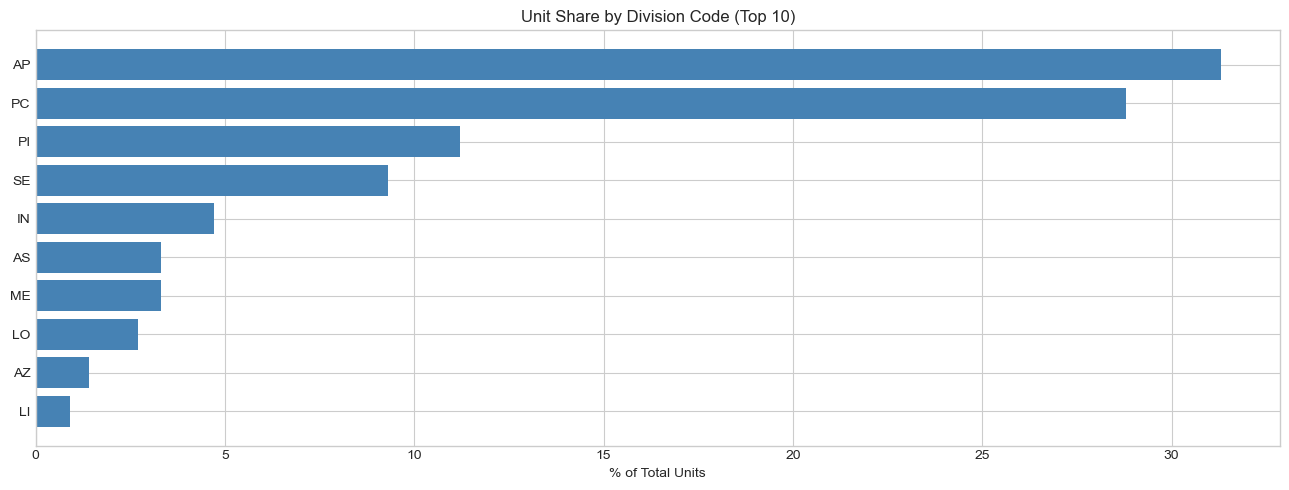

✅ Saved: division_units_breakdown.png


In [6]:
div_summary = (
    raw.groupby('Division Code corrigée')
       .agg(total_units=('Quantité facturée','sum'),
            transactions=('Quantité facturée','count'),
            avg_units_per_tx=('Quantité facturée','mean'))
       .sort_values('total_units', ascending=False).reset_index()
)
div_summary['pct_units'] = (div_summary['total_units'] / div_summary['total_units'].sum() * 100).round(1)
print(div_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(13, 5))
top10 = div_summary.head(10)
ax.barh(top10['Division Code corrigée'][::-1], top10['pct_units'][::-1], color='steelblue')
ax.set_xlabel('% of Total Units')
ax.set_title('Unit Share by Division Code (Top 10)')
plt.tight_layout()
plt.savefig(FIGURES / 'division_units_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: division_units_breakdown.png')

---
## Cell 6 — History & Coverage Check
---

In [7]:
raw['week_ending'] = raw['Date de Vente'] + pd.offsets.Week(weekday=6)

total_weeks = (raw['Date de Vente'].max() - raw['Date de Vente'].min()).days // 7
print(f'Date range  : {raw["Date de Vente"].min().date()} → {raw["Date de Vente"].max().date()}')
print(f'Total weeks : ~{total_weeks}  (~{total_weeks//52} years)')
print(f'✅ Sufficient for annual seasonality (need ≥ 2 years)\n')

g = raw.groupby(['No. magasin','Division Code corrigée'])['week_ending'].nunique().reset_index(name='n_weeks')
print(f'Total Store × Division groups : {len(g)}')
print(f'Groups ≥ 52 weeks (full year) : {int((g.n_weeks >= 52).sum())}')
print(f'Groups ≥ 26 weeks (half year) : {int((g.n_weeks >= 26).sum())}')
print(f'Groups <  10 weeks (skipped)  : {int((g.n_weeks < 10).sum())}')

Date range  : 2023-11-02 → 2026-03-10
Total weeks : ~122  (~2 years)
✅ Sufficient for annual seasonality (need ≥ 2 years)

Total Store × Division groups : 711
Groups ≥ 52 weeks (full year) : 476
Groups ≥ 26 weeks (half year) : 570
Groups <  10 weeks (skipped)  : 87


---
## Cell 7 — Unit Demand Visualizations
---

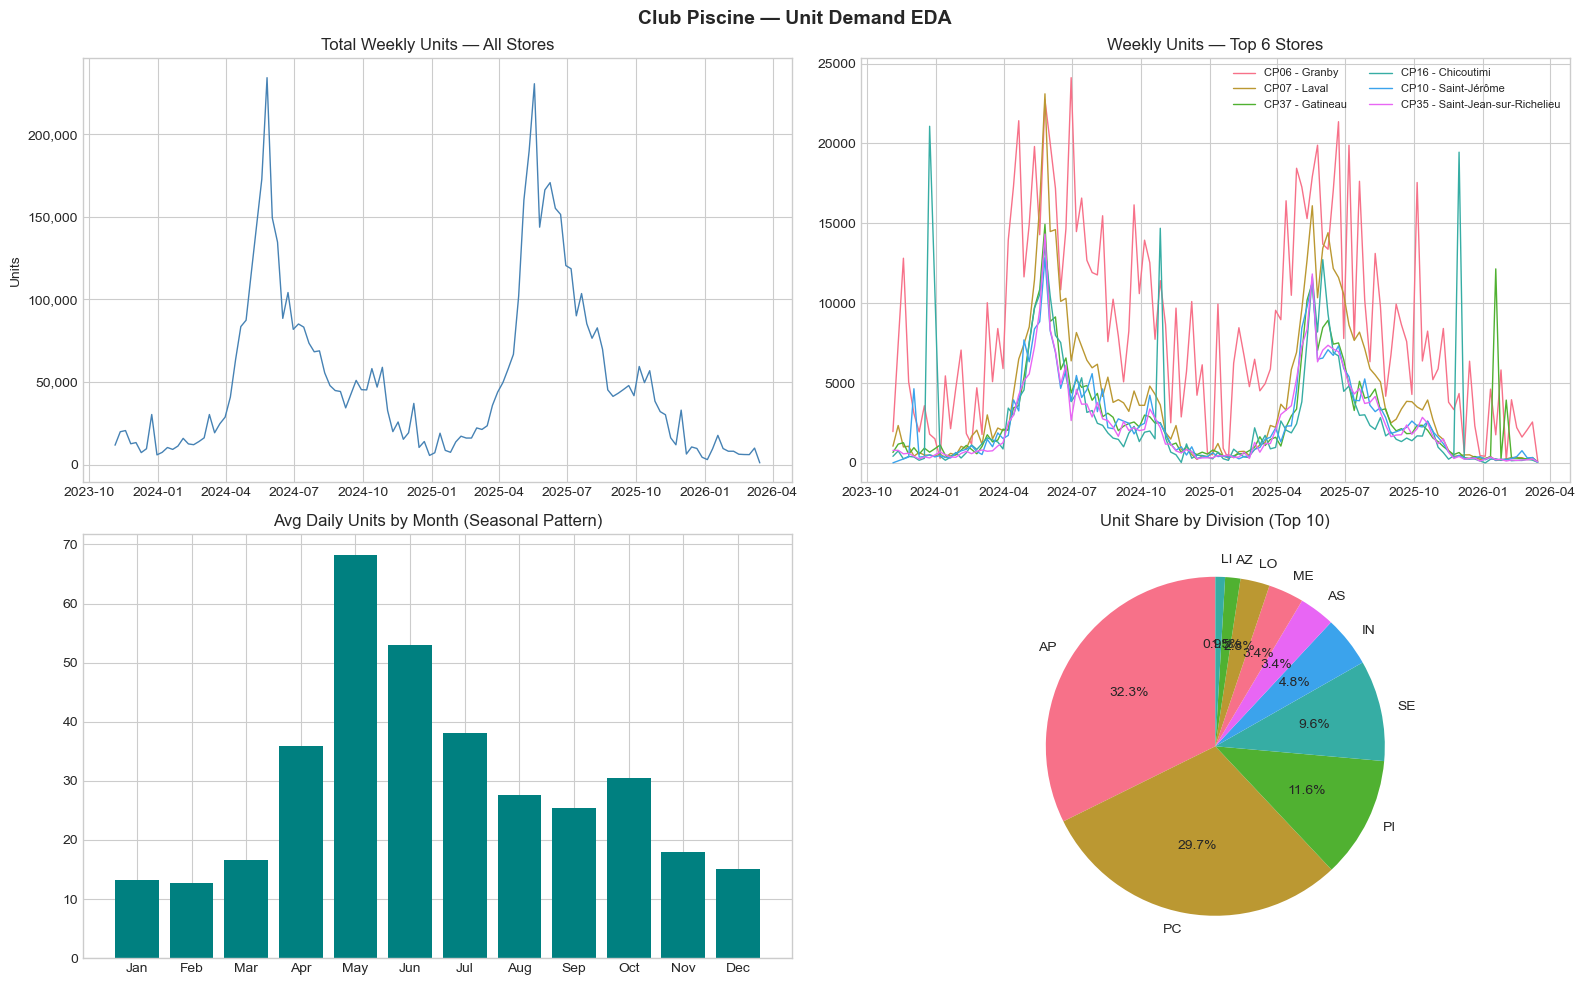

✅ Saved: units_eda_overview.png


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Weekly units — all stores
weekly_total = raw.groupby('week_ending')['Quantité facturée'].sum()
axes[0,0].plot(weekly_total.index, weekly_total.values, color='steelblue', linewidth=1)
axes[0,0].set_title('Total Weekly Units — All Stores')
axes[0,0].set_ylabel('Units')
axes[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x:,.0f}'))

# Weekly units — top 6 stores
top_stores = raw.groupby('No. magasin')['Quantité facturée'].sum().nlargest(6).index
for s in top_stores:
    d = raw[raw['No. magasin']==s].groupby('week_ending')['Quantité facturée'].sum()
    axes[0,1].plot(d.index, d.values, label=s, linewidth=1)
axes[0,1].set_title('Weekly Units — Top 6 Stores')
axes[0,1].legend(fontsize=8, ncol=2)

# Monthly seasonality
raw['month'] = raw['Date de Vente'].dt.month
month_avg = raw.groupby('month')['Quantité facturée'].mean()
axes[1,0].bar(month_avg.index, month_avg.values, color='teal')
axes[1,0].set_title('Avg Daily Units by Month (Seasonal Pattern)')
axes[1,0].set_xticks(range(1,13))
axes[1,0].set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])

# Unit share by division
div_units = raw.groupby('Division Code corrigée')['Quantité facturée'].sum().nlargest(10)
axes[1,1].pie(div_units.values, labels=div_units.index, autopct='%1.1f%%', startangle=90)
axes[1,1].set_title('Unit Share by Division (Top 10)')

plt.suptitle('Club Piscine — Unit Demand EDA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES / 'units_eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: units_eda_overview.png')

---
## Cell 8 — Weekly Aggregation (Target Variable)

Aggregate to **Week × Store × Division** — one row per group per week.
- `units` = **net units sold** (sum of Quantité facturée, clipped at 0 at weekly level)
- `gross_units` = units sold before returns
- `returns` = units returned
---

In [9]:
weekly = (
    raw.groupby(['week_ending','No. magasin','city','province','Division Code corrigée'])
       .agg(
           units          = ('Quantité facturée', 'sum'),
           gross_units    = ('Quantité facturée', lambda x: x[x > 0].sum()),
           returns        = ('Quantité facturée', lambda x: abs(x[x < 0].sum())),
           n_transactions = ('Quantité facturée', 'count')
       )
       .reset_index()
       .rename(columns={'No. magasin':'store_code', 'Division Code corrigée':'division_code'})
)

# Clip net units at 0 — a week can't have negative demand for ordering
weekly['units'] = weekly['units'].clip(lower=0)

print(f'Weekly rows  : {len(weekly):,}')
print(f'Date range   : {weekly["week_ending"].min().date()} → {weekly["week_ending"].max().date()}')
print(f'Unique weeks : {weekly["week_ending"].nunique()}')
print(f'Stores       : {weekly["store_code"].nunique()}')
print(f'Divisions    : {weekly["division_code"].nunique()}')
print(f'Groups       : {weekly.groupby(["store_code","division_code"]).ngroups}')

weekly.to_csv(DATA_PROCESSED / 'weekly_units.csv', index=False)
print(f'\n✅ Saved: weekly_units.csv')
print('Next → 02_weather_integration.ipynb')

Weekly rows  : 49,148
Date range   : 2023-11-05 → 2026-03-15
Unique weeks : 124
Stores       : 29
Divisions    : 34
Groups       : 711

✅ Saved: weekly_units.csv
Next → 02_weather_integration.ipynb
